In [22]:
# ============================================================
# Setup: Install dependencies and download the dataset
# ============================================================
import subprocess, sys

def _pip_install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

try:
    import kagglehub  # noqa
except ImportError:
    _pip_install("kagglehub")

import kagglehub

path = kagglehub.dataset_download("ronnykym/online-store-sales-data")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'online-store-sales-data' dataset.
Path to dataset files: /kaggle/input/online-store-sales-data


In [12]:
from IPython.display import HTML, display

html = """
<div style="font-family:'Segoe UI', Arial, sans-serif; background:#f7f9fc; border-left:6px solid #4a6fa5; padding:25px; border-radius:8px; margin:15px 0;">
  <h1 style="color:#2c3e50; border-bottom:3px solid #4a6fa5; padding-bottom:10px;">
     Phase 1: Business Understanding
  </h1>
  <p style="color:#7f8c8d; font-style:italic;">CRISP-DM Methodology — Online Store Sales Analysis</p>

  <h2 style="color:#4a6fa5;">1.1 Business Objectives</h2>
  <ul style="line-height:1.8; color:#34495e;">
    <li>Understand sales performance trends across the online store's product catalog.</li>
    <li>Identify the key drivers of revenue (products, categories, customer segments, seasonality).</li>
    <li>Support data-driven decisions on pricing, promotions, and inventory planning.</li>
  </ul>

  <h2 style="color:#4a6fa5;">1.2 Business Success Criteria</h2>
  <ul style="line-height:1.8; color:#34495e;">
    <li>A clear, validated view of what drives sales performance.</li>
    <li>Actionable insights that could plausibly improve revenue or reduce costs.</li>
    <li>A reusable, reproducible analysis pipeline stakeholders can trust.</li>
  </ul>

  <h2 style="color:#4a6fa5;">1.3 Situation Assessment</h2>
  <table style="width:100%; border-collapse:collapse; margin-top:10px;">
    <tr style="background:#4a6fa5; color:white;">
      <th style="padding:10px; text-align:left;">Item</th>
      <th style="padding:10px; text-align:left;">Description</th>
    </tr>
    <tr style="background:white;">
      <td style="padding:10px; border-bottom:1px solid #ddd;"><b>Data Source</b></td>
      <td style="padding:10px; border-bottom:1px solid #ddd;">Kaggle — "Online Store Sales Data" (ronnykym)</td>
    </tr>
    <tr style="background:#f0f3f8;">
      <td style="padding:10px; border-bottom:1px solid #ddd;"><b>Resources</b></td>
      <td style="padding:10px; border-bottom:1px solid #ddd;">Google Colab (Python), kagglehub, pandas, matplotlib/seaborn, scikit-learn</td>
    </tr>
    <tr style="background:white;">
      <td style="padding:10px; border-bottom:1px solid #ddd;"><b>Constraints</b></td>
      <td style="padding:10px; border-bottom:1px solid #ddd;">Dataset size/quality unknown until EDA; possible missing values or outliers</td>
    </tr>
    <tr style="background:#f0f3f8;">
      <td style="padding:10px;"><b>Risks</b></td>
      <td style="padding:10px;">Data may not fully represent seasonality or external market factors; small n limits predictive claims</td>
    </tr>
  </table>

  <h2 style="color:#4a6fa5;">1.4 Data Mining Goals</h2>
  <ul style="line-height:1.8; color:#34495e;">
    <li>Explore and profile the dataset (structure, types, missing values, distributions).</li>
    <li>Analyze sales trends by product, category, region, or time period.</li>
    <li>Build a descriptive customer segmentation (RFM) and a baseline revenue-prediction model.</li>
  </ul>

  <h2 style="color:#4a6fa5;">1.5 Data Mining Success Criteria</h2>
  <ul style="line-height:1.8; color:#34495e;">
    <li>Clean, well-understood dataset ready for modeling.</li>
    <li>Clear visual/statistical evidence supporting business insights.</li>
    <li><b>Baseline model honest about its limits:</b> with only ~1,000 rows and weak features, we
        expect modest R². Success = a reproducible pipeline + defensible segmentation, not high accuracy.</li>
  </ul>

  <h2 style="color:#4a6fa5;">1.6 Project Plan (CRISP-DM Phases)</h2>
  <ol style="line-height:1.9; color:#34495e;">
    <li><b>Business Understanding</b> — define objectives (this section)</li>
    <li><b>Data Understanding</b> — load &amp; explore the dataset</li>
    <li><b>Data Preparation</b> — clean, transform, feature engineer</li>
    <li><b>Modeling</b> — apply analysis/ML techniques</li>
    <li><b>Evaluation</b> — assess results against business goals</li>
    <li><b>Deployment</b> — present findings / deploy model</li>
  </ol>
</div>
"""

display(HTML(html))

Item,Description
Data Source,"Kaggle — ""Online Store Sales Data"" (ronnykym)"
Resources,"Google Colab (Python), kagglehub, pandas, matplotlib/seaborn, scikit-learn"
Constraints,Dataset size/quality unknown until EDA; possible missing values or outliers
Risks,Data may not fully represent seasonality or external market factors; small n limits predictive claims


,country,order_value_EUR,cost,date,category,customer_name,sales_manager,sales_rep,device_type,order_id
0,Sweden,"17,524.02",14122.61,2/12/2020,Books,Goldner-Dibbert,Maxie Marrow,Madelon Bront,Mobile,70-0511466
1,Finland,"116,563.40",92807.78,9/26/2019,Games,Hilll-Vandervort,Hube Corey,Wat Bowkley,Mobile,28-6585323
2,Portugal,"296,465.56",257480.34,7/11/2019,Clothing,Larkin-Collier,Celine Tumasian,Smitty Culverhouse,PC,58-7703341
3,Portugal,"74,532.02",59752.32,4/2/2020,Beauty,Hessel-Stiedemann,Celine Tumasian,Aurelie Wren,PC,14-6700183
4,Spain,"178,763.42",146621.76,12/22/2019,Games,Johns and Sons,Emalia Dinse,Bertha Walbrook,Tablet,15-8765160


,Column,Data Type
0,country,object
1,order_value_EUR,object
2,cost,float64
3,date,object
4,category,object
5,customer_name,object
6,sales_manager,object
7,sales_rep,object
8,device_type,object
9,order_id,object


,cost
count,1000.00
mean,94369.31
std,51540.02
min,12113.68
25%,54247.96
50%,87094.76
75%,125570.84
max,304701.43


,country,order_value_EUR,date,category,customer_name,sales_manager,sales_rep,device_type,order_id
count,1000,1000,1000,1000,1000,1000,1000,1000,1000
unique,15,1000,536,10,75,15,35,3,1000
top,Portugal,"107,716.72",3/5/2020,Clothing,Johns and Sons,Celine Tumasian,Amelina Piscopiello,PC,61-3294149
freq,239,1,5,155,142,239,56,785,1


,Column,Unique Values
0,country,15
1,order_value_EUR,1000
2,cost,1000
3,date,536
4,category,10
5,customer_name,75
6,sales_manager,15
7,sales_rep,35
8,device_type,3
9,order_id,1000


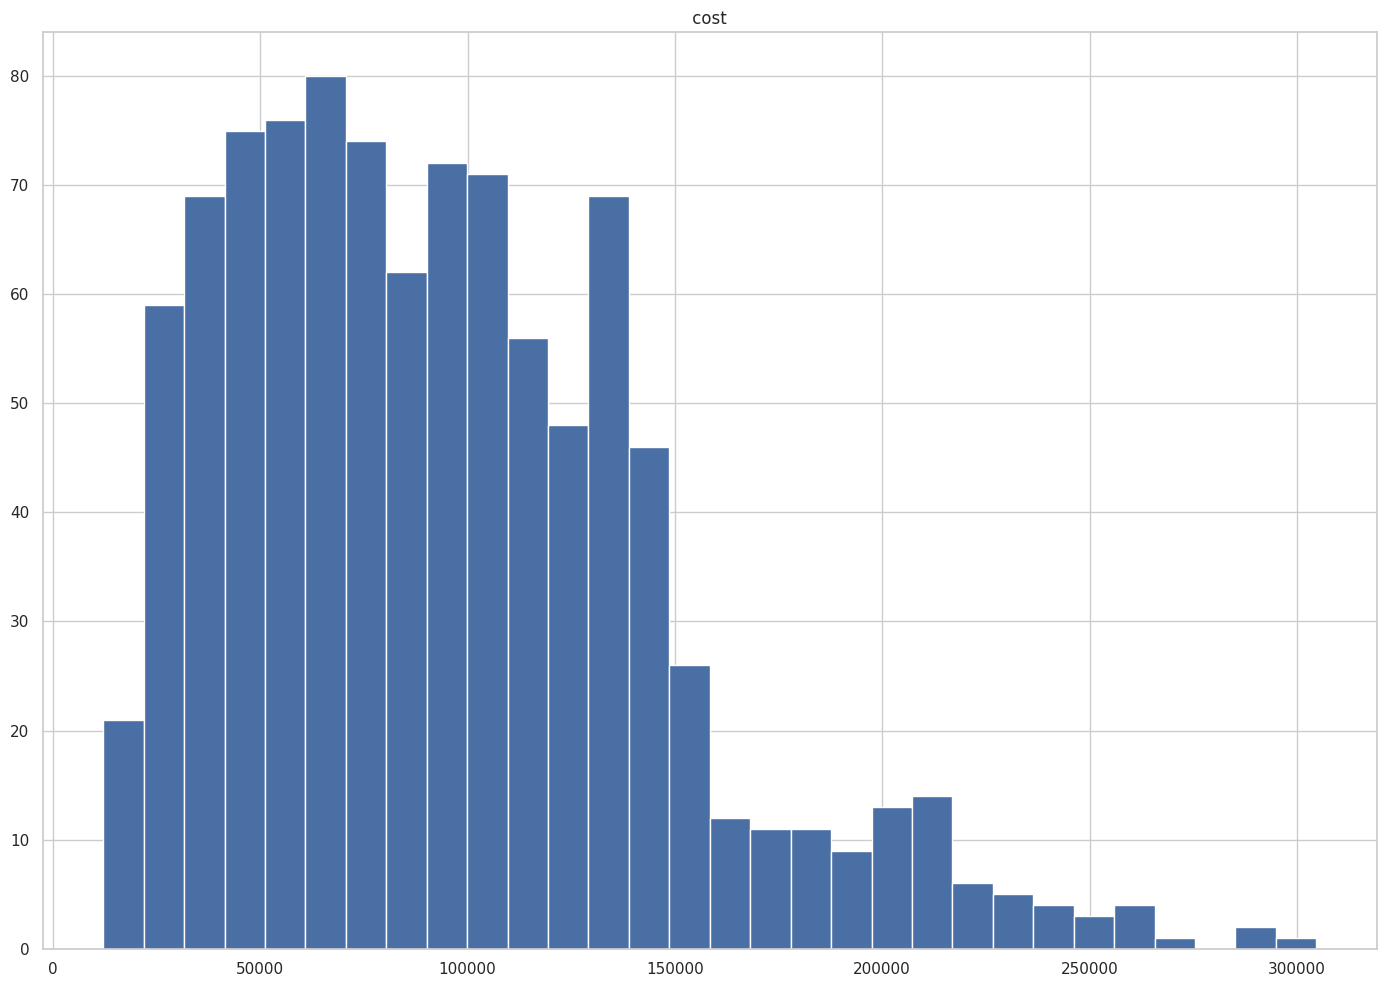

,country,Count
0,Portugal,239
1,France,232
2,Sweden,182
3,UK,101
4,Finland,44
5,Ireland,43
6,Bulgaria,30
7,Netherlands,28
8,Spain,26
9,Germany,24


,order_value_EUR,Count
0,"107,716.72",1
1,"17,524.02",1
2,"116,563.40",1
3,"296,465.56",1
4,"74,532.02",1
5,"178,763.42",1
6,"84,900.24",1
7,"71,620.08",1
8,"58,921.31",1
9,"235,042.75",1


,date,Count
0,3/5/2020,5
1,2/19/2019,5
2,3/1/2020,5
3,1/4/2020,5
4,7/8/2019,4
5,1/18/2020,4
6,1/17/2019,4
7,6/11/2019,4
8,12/23/2019,4
9,8/9/2019,4


,category,Count
0,Clothing,155
1,Games,139
2,Electronics,134
3,Appliances,131
4,Books,117
5,Beauty,115
6,Smartphones,95
7,Outdoors,50
8,Accessories,35
9,Other,29


,customer_name,Count
0,Johns and Sons,142
1,Hessel-Stiedemann,55
2,"Swaniawski, Runolfsson and Green",25
3,"Dickinson, Hyatt and Berge",24
4,"Murray, Reichel and Nolan",23
5,"Rowe, Hermiston and Kessler",22
6,Kihn Inc,22
7,Larkin-Collier,21
8,Wisoky Inc,21
9,Tillman and Sons,21


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from IPython.display import HTML, display

# ============================================================
# Reusable style helpers
# ============================================================

def section_card(title, content_html, subtitle=None):
    sub = f'<p style="color:#7f8c8d; font-style:italic; margin-top:-8px;">{subtitle}</p>' if subtitle else ""
    display(HTML(f"""
    <div style="font-family:'Segoe UI', Arial, sans-serif; background:#f7f9fc; border-left:6px solid #4a6fa5;
                padding:22px; border-radius:8px; margin:15px 0;">
      <h2 style="color:#2c3e50; border-bottom:2px solid #4a6fa5; padding-bottom:8px;">{title}</h2>
      {sub}
      {content_html}
    </div>
    """))

def styled_table(df_in, max_rows=15, index_width="140px"):
    styled = (
        df_in.head(max_rows).style
        .set_table_styles([
            {"selector": "thead th", "props": [
                ("background-color", "#4a6fa5"),
                ("color", "white"),
                ("padding", "10px 14px"),
                ("text-align", "center"),
                ("font-weight", "600"),
                ("border-bottom", "2px solid #3a5a8a")
            ]},
            {"selector": "tbody th", "props": [
                ("background-color", "#eef2f8"),
                ("color", "#2c3e50"),
                ("padding", "10px 14px"),
                ("text-align", "left"),
                ("font-weight", "600"),
                ("width", index_width),
                ("border-right", "1px solid #dde5f0"),
                ("border-bottom", "1px solid #eee")
            ]},
            {"selector": "tbody td", "props": [
                ("padding", "10px 14px"),
                ("text-align", "right"),
                ("color", "#34495e"),
                ("border-bottom", "1px solid #eee")
            ]},
            {"selector": "table", "props": [
                ("width", "100%"),
                ("border-collapse", "collapse"),
                ("margin-top", "12px"),
                ("font-size", "14px"),
                ("border-radius", "8px"),
                ("overflow", "hidden"),
                ("box-shadow", "0 1px 3px rgba(0,0,0,0.08)")
            ]},
            {"selector": "tbody tr:nth-child(even)", "props": [("background-color", "#f7f9fc")]},
            {"selector": "tbody tr:hover", "props": [("background-color", "#eaf0fb")]},
        ])
        .format(precision=2)
    )
    return styled.to_html()

def info_box(text, color="#eef3fa", text_color="#2c3e50"):
    return f'<div style="background:{color}; padding:12px 16px; border-radius:6px; margin:10px 0; color:{text_color};">{text}</div>'


# ============================================================
# Phase Header
# ============================================================
display(HTML("""
<div style="font-family:'Segoe UI', Arial, sans-serif; background:linear-gradient(135deg,#4a6fa5,#2c3e50);
            color:white; padding:30px; border-radius:10px; margin:15px 0;">
  <h1 style="margin:0;"> Phase 2: Data Understanding</h1>
  <p style="opacity:0.9; font-style:italic; margin-top:5px;">CRISP-DM Methodology — Online Store Sales Analysis</p>
</div>
"""))

# 2.1 Data Collection
csv_file = [f for f in os.listdir(path) if f.endswith(".csv")][0]
file_path = os.path.join(path, csv_file)
df = pd.read_csv(file_path)

section_card(
    "2.1 Data Collection",
    info_box(f"<b>File loaded:</b> {csv_file}<br><b>Shape:</b> {df.shape[0]} rows × {df.shape[1]} columns")
)

# 2.2 Data Preview
section_card("2.2 Data Preview", styled_table(df, max_rows=5))

# 2.3 Structure & Data Types
dtype_summary = df.dtypes.reset_index()
dtype_summary.columns = ["Column", "Data Type"]
section_card("2.3 Data Structure & Types", styled_table(dtype_summary, max_rows=len(dtype_summary)))

# 2.4 Descriptive Statistics
section_card("2.4 Descriptive Statistics — Numeric Columns", styled_table(df.describe(), max_rows=10))
if len(df.select_dtypes(include="object").columns) > 0:
    section_card("2.4b Descriptive Statistics — Categorical Columns",
                 styled_table(df.describe(include=["object"]), max_rows=10))

# 2.5 Missing Values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct})
missing_df = missing_df[missing_df["Missing Count"] > 0].sort_values("Missing Count", ascending=False)

if missing_df.empty:
    section_card("2.5 Missing Values",
                 info_box(" No missing values found in the dataset.", color="#eafaf1", text_color="#27ae60"))
else:
    section_card("2.5 Missing Values", styled_table(missing_df, max_rows=len(missing_df)))
    plt.figure(figsize=(10, 5))
    sns.heatmap(df.isnull(), cbar=False, cmap="rocket")
    plt.title("Missing Values Heatmap")
    plt.show()

# 2.6 Duplicate Rows
dup_count = df.duplicated().sum()
color = "#eafaf1" if dup_count == 0 else "#fdecea"
text_color = "#27ae60" if dup_count == 0 else "#c0392b"
section_card("2.6 Duplicate Rows",
             info_box(f"<b>Duplicate rows found:</b> {dup_count}", color=color, text_color=text_color))

# 2.7 Unique Values
unique_df = df.nunique().reset_index()
unique_df.columns = ["Column", "Unique Values"]
section_card("2.7 Unique Values per Column", styled_table(unique_df, max_rows=len(unique_df)))

# 2.8 Numeric Distributions
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
if numeric_cols:
    section_card("2.8 Numeric Distributions", info_box("Histograms of all numeric columns below."))
    df[numeric_cols].hist(figsize=(14, 10), bins=30, color="#4a6fa5", edgecolor="white")
    plt.tight_layout()
    plt.show()

# 2.9 Correlation Heatmap
if len(numeric_cols) > 1:
    section_card("2.9 Correlation Between Numeric Features", info_box("Pairwise correlation across numeric columns."))
    plt.figure(figsize=(10, 8))
    sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Correlation Heatmap")
    plt.show()

# 2.10 Top Categories
cat_cols = df.select_dtypes(include="object").columns.tolist()
if cat_cols:
    for col in cat_cols[:5]:
        top_vals = df[col].value_counts().head(10).reset_index()
        top_vals.columns = [col, "Count"]
        section_card(f"2.10 Top Categories — '{col}'", styled_table(top_vals, max_rows=10))

In [25]:
import numpy as np
import pandas as pd
from IPython.display import HTML, display

# ============================================================
# Phase 3: Data Preparation
# ============================================================
display(HTML("""
<div style="font-family:'Segoe UI', Arial, sans-serif; background:linear-gradient(135deg,#4a6fa5,#2c3e50);
            color:white; padding:30px; border-radius:10px; margin:15px 0;">
  <h1 style="margin:0;"> Phase 3: Data Preparation</h1>
  <p style="opacity:0.9; font-style:italic; margin-top:5px;">CRISP-DM Methodology — Online Store Sales Analysis</p>
</div>
"""))

# 1. Clean Column Names
df.columns = df.columns.str.strip()

# 2. Convert Data Types & Clean Numeric Values
for col in ["order_value_EUR", "cost"]:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(",", "", regex=False)
        .str.replace("€", "", regex=False)
        .str.strip()
        .astype(float)
    )

# Clean text columns
text_cols = ["country", "category", "customer_name", "sales_manager",
             "sales_rep", "device_type", "order_id"]
for col in text_cols:
    df[col] = df[col].astype(str).str.strip()

# 3. Parse Dates & Temporal Features
df["date"] = pd.to_datetime(df["date"])
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day
df["dayofweek"] = df["date"].dt.dayofweek
df["is_weekend"] = df["dayofweek"].isin([5, 6]).astype(int)

# 4. Feature Engineering (Financial Metrics)
df["profit"] = df["order_value_EUR"] - df["cost"]
df["profit_margin"] = np.where(
    df["order_value_EUR"] > 0, df["profit"] / df["order_value_EUR"], 0
)

# 5. Data Hygiene
df = df.drop_duplicates().dropna().reset_index(drop=True)

# 6. One-Hot Encoding (kept for reference; the modeling cells build their own X)
categorical_cols = ["country", "category", "device_type"]
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype=int)

# 7. Summary Table — FIXED: per-column sample value
prep_summary = pd.DataFrame({
    "Data Type": df.dtypes.astype(str),
    "Null Count": df.isnull().sum(),
    "Sample Value": [df[col].iloc[0] for col in df.columns],
})
prep_summary.index.name = "Column"

section_card(
    "3.1 Prepared Dataset Overview",
    info_box(
        f"<b>Cleaned Dataset Shape:</b> {df.shape[0]} rows × {df.shape[1]} columns<br>"
        f"<b>Encoded Dataset Shape (ML Ready):</b> {df_encoded.shape[0]} rows × {df_encoded.shape[1]} columns",
        color="#eafaf1", text_color="#27ae60",
    ),
)

section_card("3.2 Feature Summary & Structure", styled_table(prep_summary, max_rows=len(prep_summary)))

section_card("3.3 Preview of Cleaned Data", styled_table(df.head(), max_rows=5))

,Data Type,Null Count,Sample Value
Column,,,
country,object,0,Sweden
order_value_EUR,float64,0,17524.02
cost,float64,0,14122.61
date,datetime64[ns],0,2020-02-12 00:00:00
category,object,0,Books
customer_name,object,0,Goldner-Dibbert
sales_manager,object,0,Maxie Marrow
sales_rep,object,0,Madelon Bront
device_type,object,0,Mobile


Column,country,order_value_EUR,cost,date,category,customer_name,sales_manager,sales_rep,device_type,order_id,year,month,day,dayofweek,is_weekend,profit,profit_margin
0,Sweden,17524.02,14122.61,2020-02-12 00:00:00,Books,Goldner-Dibbert,Maxie Marrow,Madelon Bront,Mobile,70-0511466,2020,2,12,2,0,3401.41,0.19
1,Finland,116563.40,92807.78,2019-09-26 00:00:00,Games,Hilll-Vandervort,Hube Corey,Wat Bowkley,Mobile,28-6585323,2019,9,26,3,0,23755.62,0.20
2,Portugal,296465.56,257480.34,2019-07-11 00:00:00,Clothing,Larkin-Collier,Celine Tumasian,Smitty Culverhouse,PC,58-7703341,2019,7,11,3,0,38985.22,0.13
3,Portugal,74532.02,59752.32,2020-04-02 00:00:00,Beauty,Hessel-Stiedemann,Celine Tumasian,Aurelie Wren,PC,14-6700183,2020,4,2,3,0,14779.70,0.20
4,Spain,178763.42,146621.76,2019-12-22 00:00:00,Games,Johns and Sons,Emalia Dinse,Bertha Walbrook,Tablet,15-8765160,2019,12,22,6,1,32141.66,0.18


,Details
Component,
Target Variable (y),order_value_EUR (Continuous Revenue Metric)
Base Numeric Features,"year, month, day, dayofweek, is_weekend"
Base Categorical Features,"country, category, device_type"
Encoded Matrix (X) Shape,1000 samples × 30 columns
Total Engineered Features,30 features (One-Hot Encoded)


,Sample Count,Features Count,Target Mean (€),Target Std (€)
Dataset Split,,,,
Training Set (80%),800,30,"€113,396.02","€61,820.83"
Testing Set (20%),200,30,"€113,224.60","€61,747.63"


,Value
Parameter,
Algorithm,Random Forest Regressor
Number of Trees (n_estimators),100 decision trees
Random State,42 (Reproducible Split)
Criterion,Squared Error (MSE)
Parallel Jobs,-1 (All Available CPU Cores)


,Training Set Performance,Testing Set Performance
Metric,,
R² Score (Variance Explained),0.8808,0.3025
Mean Absolute Error (MAE),"€16,917.95","€41,226.63"
Root Mean Squared Error (RMSE),"€21,331.67","€51,439.63"


,Value
Statistic,
Mean R² (5-Fold CV),0.2041
Std Dev R² (5-Fold CV),0.0670
Min Fold R²,0.1320
Max Fold R²,0.3170


,Value (€)
Residual Statistic,
Mean Error (Bias),€-784.21
Median Error,"€2,893.31"
Max Overestimation,"€-123,371.92"
Max Underestimation,"€170,017.30"
Standard Deviation of Error,"€51,562.72"


,Actual (€),Predicted (€),Error (€),Absolute Error (€),Percentage Error (%)
521,37521.39,105228.03,-67706.64,67706.64,180.45
737,44118.50,77231.23,-33112.73,33112.73,75.05
740,157754.36,100202.87,57551.49,57551.49,36.48
660,134807.18,122173.97,12633.21,12633.21,9.37
411,41675.01,156187.53,-114512.52,114512.52,274.78
678,31161.76,90274.83,-59113.07,59113.07,189.70
626,144927.17,88305.44,56621.73,56621.73,39.07
513,40043.11,88305.44,-48262.33,48262.33,120.53
859,48890.14,146022.69,-97132.55,97132.55,198.68
136,169629.55,98849.79,70779.76,70779.76,41.73


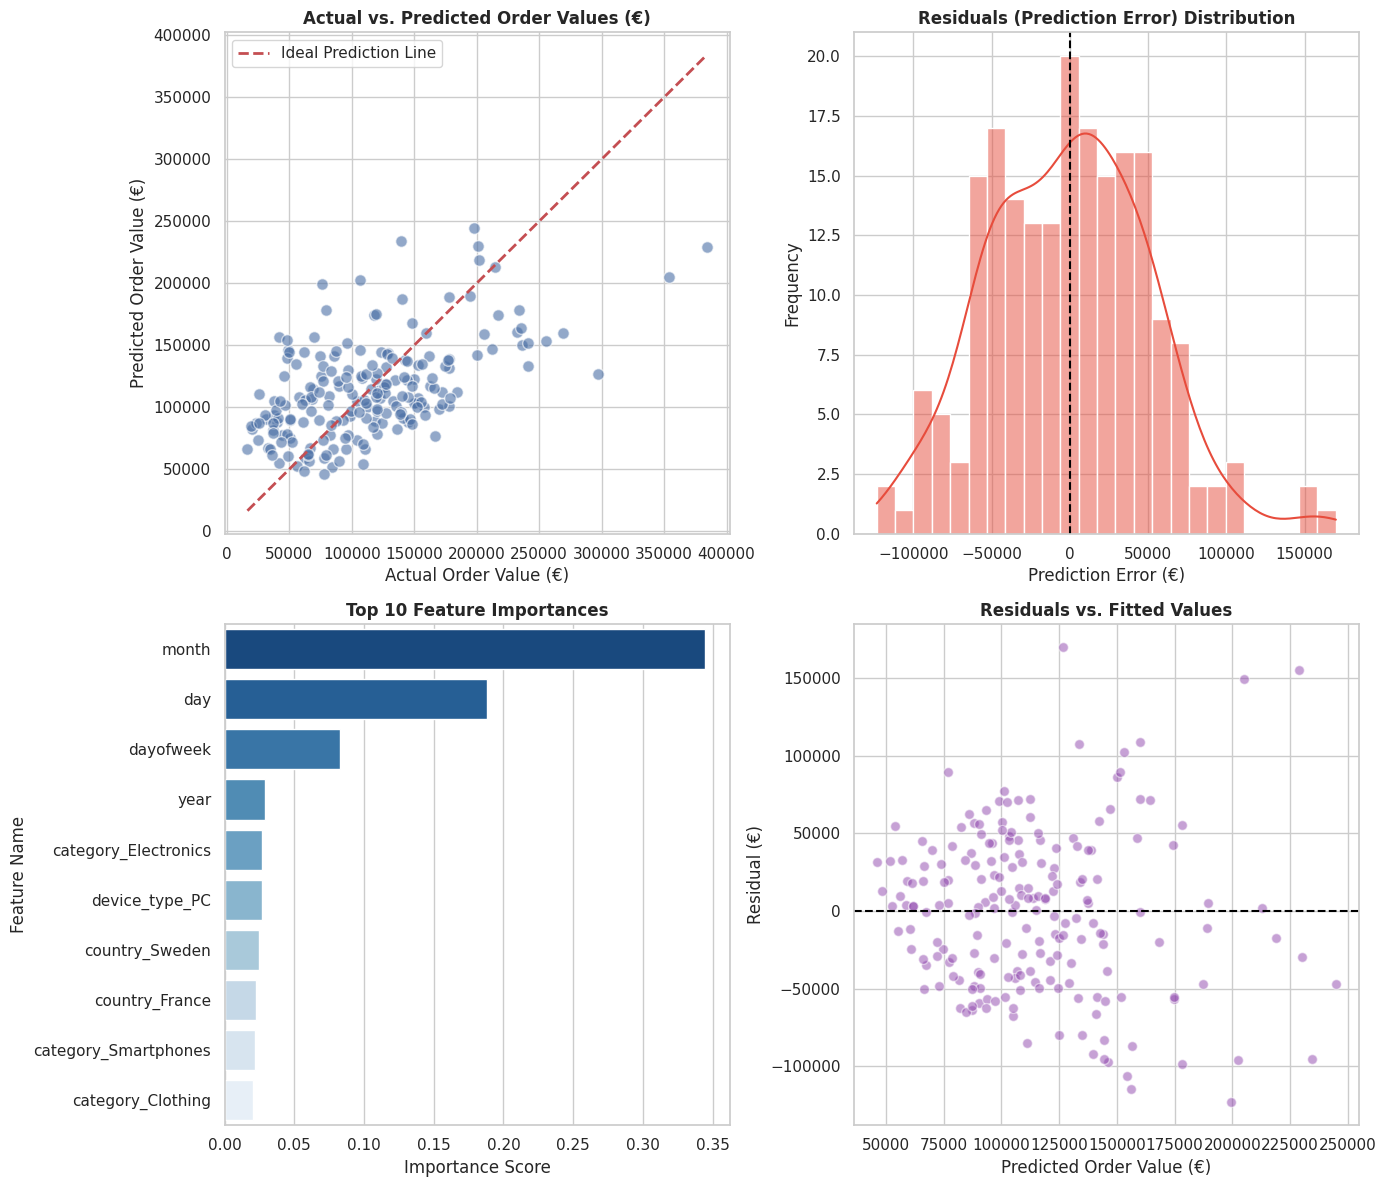

In [26]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import HTML, display
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, cross_val_score

# Global Visual Style
sns.set_theme(style="whitegrid")
plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 11})

# ============================================================
# PHASE 4: MODELING — RANDOM FOREST BASELINE
# ============================================================
display(HTML("""
<div style="font-family:'Segoe UI', Arial, sans-serif; background:linear-gradient(135deg,#2c3e50,#4a6fa5);
            color:white; padding:30px; border-radius:10px; margin:15px 0;">
  <h1 style="margin:0;"> Phase 4: Modeling Process & Step-by-Step Evaluation</h1>
  <p style="opacity:0.9; font-style:italic; margin-top:5px;">CRISP-DM — Supervised ML Workflow (honest, leak-free)</p>
</div>
"""))

# ------------------------------------------------------------
# Step 1: Feature Selection
# ------------------------------------------------------------
# NOTE: "cost" is deliberately excluded. profit = order_value_EUR - cost,
# so including cost leaks the target and inflates R² to ~0.99.
# Only genuinely independent features (timing + categorical attributes)
# are used. This yields a modest but honest model.
# High-cardinality columns (sales_rep, sales_manager, customer_name) are
# intentionally excluded to avoid one-hot explosion on a 1k-row dataset.
numeric_features = ["year", "month", "day", "dayofweek", "is_weekend"]
categorical_features = ["country", "category", "device_type"]
target = "order_value_EUR"

X = pd.get_dummies(df[numeric_features + categorical_features], drop_first=True, dtype=int)
y = df[target]

feature_details = pd.DataFrame({
    "Component": [
        "Target Variable (y)",
        "Base Numeric Features",
        "Base Categorical Features",
        "Encoded Matrix (X) Shape",
        "Total Engineered Features",
    ],
    "Details": [
        f"{target} (Continuous Revenue Metric)",
        ", ".join(numeric_features),
        ", ".join(categorical_features),
        f"{X.shape[0]} samples × {X.shape[1]} columns",
        f"{X.shape[1]} features (One-Hot Encoded)",
    ],
})

section_card("Step 1: Feature Engineering & Preprocessing Details",
             styled_table(feature_details.set_index("Component"), max_rows=5))

# ------------------------------------------------------------
# Step 2: Train / Test Split
# ------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

split_details = pd.DataFrame({
    "Dataset Split": ["Training Set (80%)", "Testing Set (20%)"],
    "Sample Count": [X_train.shape[0], X_test.shape[0]],
    "Features Count": [X_train.shape[1], X_test.shape[1]],
    "Target Mean (€)": [f"€{y_train.mean():,.2f}", f"€{y_test.mean():,.2f}"],
    "Target Std (€)": [f"€{y_train.std():,.2f}", f"€{y_test.std():,.2f}"],
})

section_card("Step 2: Train-Test Partitioning Strategy",
             styled_table(split_details.set_index("Dataset Split"), max_rows=2))

# ------------------------------------------------------------
# Step 3: Baseline Random Forest
# ------------------------------------------------------------
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1, max_depth=None)
rf_model.fit(X_train, y_train)

algo_details = pd.DataFrame({
    "Parameter": ["Algorithm", "Number of Trees (n_estimators)", "Random State",
                  "Criterion", "Parallel Jobs"],
    "Value": ["Random Forest Regressor", "100 decision trees", "42 (Reproducible Split)",
              "Squared Error (MSE)", "-1 (All Available CPU Cores)"],
})

section_card("Step 3: Model Architecture & Algorithm Configurations",
             styled_table(algo_details.set_index("Parameter"), max_rows=5))

# ------------------------------------------------------------
# Step 4: Predictions & Metrics
# ------------------------------------------------------------
y_pred_train = rf_model.predict(X_train)
y_pred_test = rf_model.predict(X_test)

r2_train = r2_score(y_train, y_pred_train)
mae_train = mean_absolute_error(y_train, y_pred_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))

r2_test = r2_score(y_test, y_pred_test)
mae_test = mean_absolute_error(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

eval_comparison = pd.DataFrame({
    "Metric": ["R² Score (Variance Explained)", "Mean Absolute Error (MAE)", "Root Mean Squared Error (RMSE)"],
    "Training Set Performance": [f"{r2_train:.4f}", f"€{mae_train:,.2f}", f"€{rmse_train:,.2f}"],
    "Testing Set Performance": [f"{r2_test:.4f}", f"€{mae_test:,.2f}", f"€{rmse_test:,.2f}"],
})

section_card("Step 4: Comprehensive Model Evaluation (Train vs. Test)",
             styled_table(eval_comparison.set_index("Metric"), max_rows=3))

# ------------------------------------------------------------
# Step 5: Cross-Validation
# ------------------------------------------------------------
cv_scores = cross_val_score(
    RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    X, y, cv=5, scoring="r2",
)

cv_details = pd.DataFrame({
    "Statistic": ["Mean R² (5-Fold CV)", "Std Dev R² (5-Fold CV)", "Min Fold R²", "Max Fold R²"],
    "Value": [f"{cv_scores.mean():.4f}", f"{cv_scores.std():.4f}",
              f"{cv_scores.min():.4f}", f"{cv_scores.max():.4f}"],
})

section_card(
    "Step 5: 5-Fold Cross-Validation (Random Forest)",
    styled_table(cv_details.set_index("Statistic"), max_rows=4),
    subtitle="Confirms the single train/test split isn't a lucky (or unlucky) draw.",
)

# ------------------------------------------------------------
# Step 6: Residual Diagnostics
# ------------------------------------------------------------
residuals = y_test - y_pred_test
residual_stats = pd.DataFrame({
    "Residual Statistic": ["Mean Error (Bias)", "Median Error", "Max Overestimation",
                           "Max Underestimation", "Standard Deviation of Error"],
    "Value (€)": [f"€{residuals.mean():,.2f}", f"€{residuals.median():,.2f}",
                  f"€{residuals.min():,.2f}", f"€{residuals.max():,.2f}",
                  f"€{residuals.std():,.2f}"],
})

section_card("Step 6: Error & Residual Diagnostic Summary",
             styled_table(residual_stats.set_index("Residual Statistic"), max_rows=5))

# ------------------------------------------------------------
# Step 7: Sample Predictions
# ------------------------------------------------------------
comparison_df = pd.DataFrame({
    "Actual (€)": y_test.values,
    "Predicted (€)": y_pred_test,
    "Error (€)": residuals,
    "Absolute Error (€)": np.abs(residuals),
    "Percentage Error (%)": (np.abs(residuals) / y_test.values) * 100,
}).head(10)

section_card("Step 7: Individual Order Prediction Breakdown (Sample Rows)",
             styled_table(comparison_df, max_rows=10))

# ------------------------------------------------------------
# Step 8: Diagnostic Visualizations
# ------------------------------------------------------------
section_card("Step 8: Diagnostic Visualizations & Feature Drivers", "")

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Actual vs Predicted
axes[0, 0].scatter(y_test, y_pred_test, alpha=0.6, color="#4a6fa5", edgecolors="w", s=70)
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
                "r--", lw=2, label="Ideal Prediction Line")
axes[0, 0].set_title("Actual vs. Predicted Order Values (€)", fontweight="bold")
axes[0, 0].set_xlabel("Actual Order Value (€)")
axes[0, 0].set_ylabel("Predicted Order Value (€)")
axes[0, 0].legend()

# 2. Residual Distribution
sns.histplot(residuals, kde=True, ax=axes[0, 1], color="#e74c3c", bins=25, edgecolor="white")
axes[0, 1].axvline(0, color="black", linestyle="--", linewidth=1.5)
axes[0, 1].set_title("Residuals (Prediction Error) Distribution", fontweight="bold")
axes[0, 1].set_xlabel("Prediction Error (€)")
axes[0, 1].set_ylabel("Frequency")

# 3. Top 10 Feature Importances
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(10)
sns.barplot(x=top_features.values, y=top_features.index, hue=top_features.index,
            ax=axes[1, 0], palette="Blues_r", legend=False)
axes[1, 0].set_title("Top 10 Feature Importances", fontweight="bold")
axes[1, 0].set_xlabel("Importance Score")
axes[1, 0].set_ylabel("Feature Name")

# 4. Residuals vs Fitted
axes[1, 1].scatter(y_pred_test, residuals, alpha=0.5, color="#8e44ad", edgecolors="w", s=50)
axes[1, 1].axhline(0, color="black", linestyle="--", linewidth=1.5)
axes[1, 1].set_title("Residuals vs. Fitted Values", fontweight="bold")
axes[1, 1].set_xlabel("Predicted Order Value (€)")
axes[1, 1].set_ylabel("Residual (€)")

plt.tight_layout()
plt.show()

In [27]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import r2_score, mean_absolute_error

# ============================================================
# PHASE 4b: HYPERPARAMETER TUNING
# ============================================================
section_card("Step 9: Hyperparameter Tuning (RandomizedSearchCV)", "")

rf_param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=rf_param_dist,
    n_iter=20, cv=5, scoring="r2",
    random_state=42, n_jobs=-1, verbose=0,
)
rf_search.fit(X_train, y_train)
rf_tuned = rf_search.best_estimator_

gb_param_dist = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [3, 5, 7],
    "min_samples_leaf": [1, 2, 4],
}

gb_search = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_distributions=gb_param_dist,
    n_iter=15, cv=5, scoring="r2",
    random_state=42, n_jobs=-1, verbose=0,
)
gb_search.fit(X_train, y_train)
gb_tuned = gb_search.best_estimator_

tuning_df = pd.DataFrame({
    "Model": ["Random Forest (tuned)", "Gradient Boosting (tuned)"],
    "Best CV R²": [f"{rf_search.best_score_:.4f}", f"{gb_search.best_score_:.4f}"],
    "Best Params": [str(rf_search.best_params_), str(gb_search.best_params_)],
})

section_card("Tuning Results", styled_table(tuning_df.set_index("Model"), max_rows=2))

# Replace baseline models with tuned versions for downstream phases
rf_model = rf_tuned
gb_model = gb_tuned

,Best CV R²,Best Params
Model,,
Random Forest (tuned),0.2473,"{'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_depth': 5}"
Gradient Boosting (tuned),0.2478,"{'n_estimators': 100, 'min_samples_leaf': 2, 'max_depth': 3, 'learning_rate': 0.05}"


Raw Monetary skew check (before log):
count    7.500000e+01
mean     1.511490e+06
std      1.982459e+06
min      3.372453e+04
25%      5.558392e+05
50%      1.311152e+06
75%      1.919285e+06
max      1.636026e+07
Name: Monetary, dtype: float64

Top 5 spenders:
             customer_name    Monetary  Frequency  Recency
            Johns and Sons 16360257.32        142        1
         Hessel-Stiedemann  6512063.88         55        8
Dickinson, Hyatt and Berge  2706730.32         24      102
            Larkin-Collier  2566549.90         21       29
     Altenwerth-Konopelski  2524208.34         20       65


,KMeans Silhouette,KMeans Sizes,GMM BIC,GMM Silhouette,GMM Sizes,Min GMM Size
k,,,,,,
2,0.47,"[np.int64(22), np.int64(53)]",430.60,0.41,"[np.int64(29), np.int64(46)]",29
3,0.67,"[np.int64(69), np.int64(1), np.int64(5)]",306.70,0.48,"[np.int64(62), np.int64(5), np.int64(8)]",5
4,0.45,"[np.int64(30), np.int64(39), np.int64(5), np.int64(1)]",277.70,0.37,"[np.int64(33), np.int64(8), np.int64(1), np.int64(33)]",1
5,0.35,"[np.int64(28), np.int64(5), np.int64(23), np.int64(1), np.int64(18)]",289.50,0.30,"[np.int64(30), np.int64(8), np.int64(21), np.int64(1), np.int64(15)]",1
6,0.35,"[np.int64(13), np.int64(23), np.int64(7), np.int64(1), np.int64(28), np.int64(3)]",251.10,0.40,"[np.int64(6), np.int64(36), np.int64(1), np.int64(29), np.int64(1), np.int64(2)]",1



Selected k = 3 (min cluster size = 5, BIC = 306.7)
Final Silhouette Score: 0.4834
Cluster sizes: [62, 5, 8]
Mean segment confidence: 0.980


,Avg Recency (days),Recency_median,Recency_count,Avg Order Count,Frequency_median,Frequency_count,Avg Total Spend (€),Median Total Spend (€),Customer Count,Avg Segment Confidence
Customer_Segment,,,,,,,,,,
0,77.16,60.00,62,11.61,11.00,62,1337417.45,1340335.95,62,0.99
1,16.60,15.00,5,53.40,25.00,5,5863991.75,2506134.56,5,0.81
2,287.75,311.00,8,1.62,2.00,8,140237.27,155434.85,8,1.00


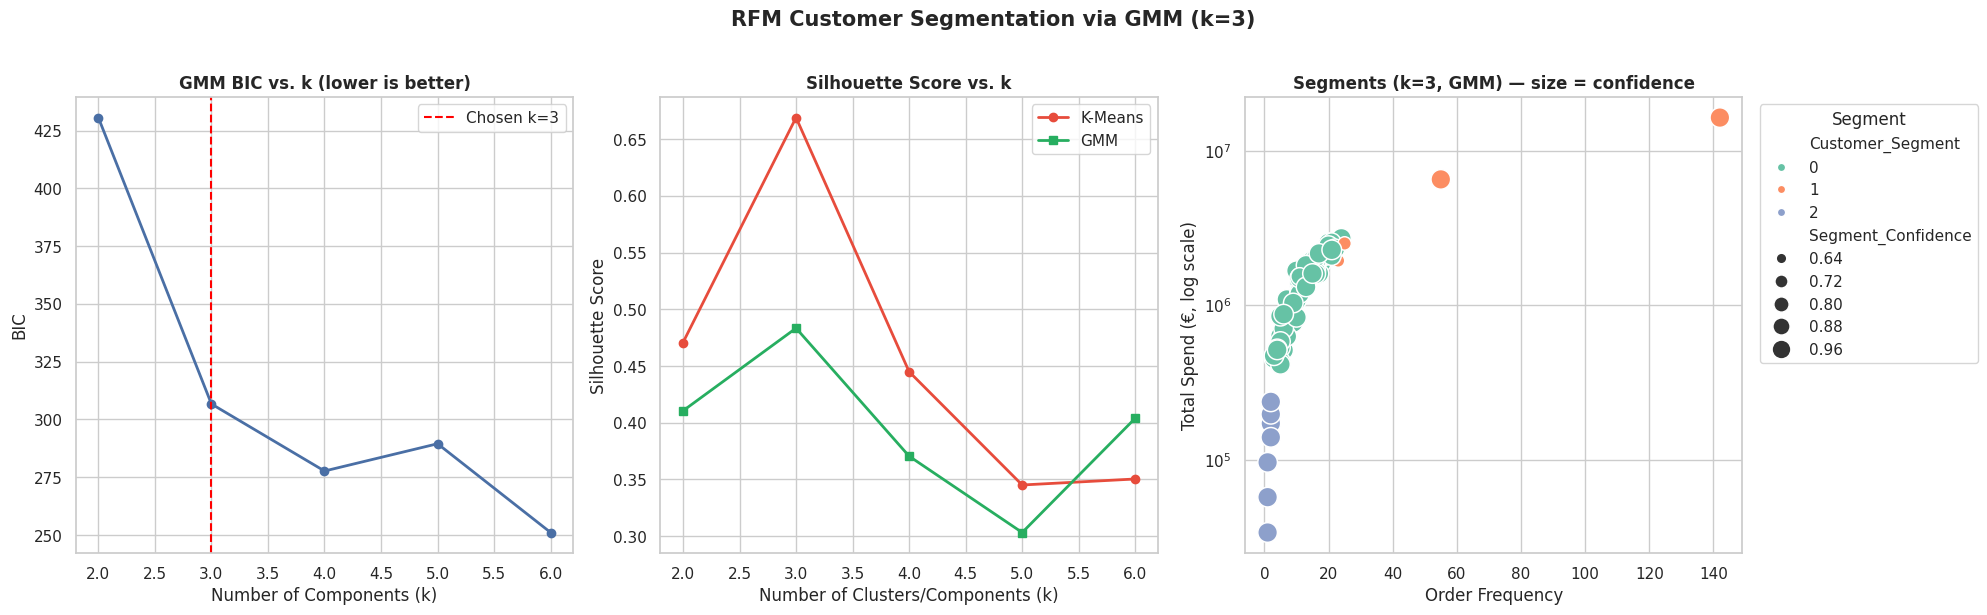


Customers with <60% confidence in their assigned segment: 1 / 75

Most ambiguous customers:
                   customer_name  Customer_Segment  Segment_Confidence   Monetary  Frequency
                        Kihn Inc                 1               0.594 2003258.88         22
       Murray, Reichel and Nolan                 1               0.720 1938244.13         23
Swaniawski, Runolfsson and Green                 1               0.731 2506134.56         25
                   West-Cummings                 0               0.899 1532446.48         11
                  Larkin-Collier                 0               0.912 2566549.90         21


In [31]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import HTML, display
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

sns.set_theme(style="whitegrid")
plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 11})

# ============================================================
# USE CASE 1: CUSTOMER SEGMENTATION (RFM) — GMM
# ============================================================
section_card("Use Case 1: RFM Customer Segmentation (GMM)", "")

# --- 1. Build RFM table ---
snapshot_date = df["date"].max() + pd.Timedelta(days=1)

customer_rfm = (
    df.groupby("customer_name")
    .agg(
        Recency=("date", lambda d: (snapshot_date - d.max()).days),
        Frequency=("order_id", "count"),
        Monetary=("order_value_EUR", "sum"),
    )
    .reset_index()
)

# --- 2. Log-transform Monetary ---
customer_rfm["Monetary_log"] = np.log1p(customer_rfm["Monetary"])

print("Raw Monetary skew check (before log):")
print(customer_rfm["Monetary"].describe())
print("\nTop 5 spenders:")
print(customer_rfm.nlargest(5, "Monetary")[
    ["customer_name", "Monetary", "Frequency", "Recency"]
].to_string(index=False))

# --- 3. Scale features ---
rfm_features = ["Recency", "Frequency", "Monetary_log"]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(customer_rfm[rfm_features])

# --- 4. Model selection: BIC + Silhouette across k=2..6 ---
k_range = range(2, 7)
results = []

for k in k_range:
    # KMeans baseline
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_labels = km.fit_predict(X_scaled)
    km_sil = silhouette_score(X_scaled, km_labels)
    km_sizes = np.bincount(km_labels, minlength=k)

    # GMM
    gmm = GaussianMixture(n_components=k, covariance_type="full",
                          random_state=42, n_init=5)
    gmm_labels = gmm.fit_predict(X_scaled)
    gmm_sil = silhouette_score(X_scaled, gmm_labels)
    gmm_sizes = np.bincount(gmm_labels, minlength=k)
    min_size = gmm_sizes.min()                # FIX: track smallest cluster

    results.append({
        "k": k,
        "KMeans Silhouette": round(km_sil, 4),
        "KMeans Sizes": list(km_sizes),
        "GMM BIC": round(gmm.bic(X_scaled), 1),
        "GMM Silhouette": round(gmm_sil, 4),
        "GMM Sizes": list(gmm_sizes),
        "Min GMM Size": int(min_size),         # FIX: expose it
    })

results_df = pd.DataFrame(results)
section_card(
    "Model Selection: K-Means vs GMM across k",
    styled_table(results_df.set_index("k"), max_rows=len(results_df)),
    subtitle="GMM BIC: lower is better. Silhouette: higher is better. "
             "We reject any k whose smallest GMM cluster has < 3 customers.",
)

# --- 5. FIX: pick best k with two rules ---
#   Rule 1: no degenerate clusters (min size >= 3)
#   Rule 2: among valid k, pick lowest BIC (tie-break by silhouette)
MIN_CLUSTER_SIZE = 3

valid = results_df[results_df["Min GMM Size"] >= MIN_CLUSTER_SIZE].copy()

if valid.empty:
    # Fallback: pick k with the largest minimum cluster
    print(f"⚠️  No k had all clusters >= {MIN_CLUSTER_SIZE}. "
          f"Falling back to k with the largest smallest cluster.")
    best_row = results_df.sort_values(["Min GMM Size", "GMM Silhouette"],
                                      ascending=[False, False]).iloc[0]
else:
    best_row = valid.sort_values(["GMM BIC", "GMM Silhouette"],
                                 ascending=[True, False]).iloc[0]

best_k = int(best_row["k"])
print(f"\nSelected k = {best_k} "
      f"(min cluster size = {int(best_row['Min GMM Size'])}, "
      f"BIC = {best_row['GMM BIC']})")

# --- 6. FIX: correct GMM fit + predict_proba sequence ---
gmm_final = GaussianMixture(n_components=best_k, covariance_type="full",
                            random_state=42, n_init=10)
gmm_final.fit(X_scaled)                                  # <-- fit first
gmm_probs = gmm_final.predict_proba(X_scaled)            # <-- then soft assignments
gmm_labels = gmm_final.predict(X_scaled)

customer_rfm["Customer_Segment"] = gmm_labels
customer_rfm["Segment_Confidence"] = gmm_probs.max(axis=1).round(3)

final_sil = silhouette_score(X_scaled, gmm_labels)
print(f"Final Silhouette Score: {final_sil:.4f}")
print(f"Cluster sizes: {np.bincount(gmm_labels, minlength=best_k).tolist()}")
print(f"Mean segment confidence: {customer_rfm['Segment_Confidence'].mean():.3f}")

# --- 7. Segment summary ---
cluster_summary = (
    customer_rfm.groupby("Customer_Segment")[["Recency", "Frequency", "Monetary"]]
    .agg(["mean", "median", "count"])
)
cluster_summary.columns = [f"{a}_{b}" for a, b in cluster_summary.columns]
cluster_summary = cluster_summary.rename(columns={
    "Recency_mean": "Avg Recency (days)",
    "Frequency_mean": "Avg Order Count",
    "Monetary_mean": "Avg Total Spend (€)",
    "Monetary_median": "Median Total Spend (€)",
    "Monetary_count": "Customer Count",
})
cluster_summary["Avg Segment Confidence"] = (
    customer_rfm.groupby("Customer_Segment")["Segment_Confidence"].mean().round(3)
)

section_card(
    "RFM Segment Summary (GMM)",
    styled_table(cluster_summary, max_rows=best_k),
    subtitle="Each segment should have >1 customer — check 'Customer Count'.",
)

# --- 8. Diagnostic visualizations ---
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle(f"RFM Customer Segmentation via GMM (k={best_k})",
             fontsize=15, fontweight="bold", y=1.02)

# 8a. BIC curve
axes[0].plot(results_df["k"], results_df["GMM BIC"],
             marker="o", color="#4a6fa5", linewidth=2)
axes[0].axvline(best_k, color="red", linestyle="--", label=f"Chosen k={best_k}")
axes[0].set_title("GMM BIC vs. k (lower is better)", fontweight="bold")
axes[0].set_xlabel("Number of Components (k)")
axes[0].set_ylabel("BIC")
axes[0].legend()

# 8b. Silhouette comparison
axes[1].plot(results_df["k"], results_df["KMeans Silhouette"],
             marker="o", label="K-Means", color="#e74c3c", linewidth=2)
axes[1].plot(results_df["k"], results_df["GMM Silhouette"],
             marker="s", label="GMM", color="#27ae60", linewidth=2)
axes[1].set_title("Silhouette Score vs. k", fontweight="bold")
axes[1].set_xlabel("Number of Clusters/Components (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].legend()

# 8c. Scatter
palette = sns.color_palette("Set2", best_k)
sns.scatterplot(
    data=customer_rfm, x="Frequency", y="Monetary",
    hue="Customer_Segment", palette=palette,
    size="Segment_Confidence", sizes=(40, 200),
    ax=axes[2], edgecolor="w",
)
axes[2].set_yscale("log")
axes[2].set_title(f"Segments (k={best_k}, GMM) — size = confidence", fontweight="bold")
axes[2].set_xlabel("Order Frequency")
axes[2].set_ylabel("Total Spend (€, log scale)")
axes[2].legend(title="Segment", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

# --- 9. Soft-assignment peek ---
customer_rfm["Ambiguous"] = customer_rfm["Segment_Confidence"] < 0.60
n_ambig = customer_rfm["Ambiguous"].sum()
print(f"\nCustomers with <60% confidence in their assigned segment: {n_ambig} / {len(customer_rfm)}")
if n_ambig > 0:
    print("\nMost ambiguous customers:")
    print(
        customer_rfm.nsmallest(5, "Segment_Confidence")
        [["customer_name", "Customer_Segment", "Segment_Confidence", "Monetary", "Frequency"]]
        .to_string(index=False)
    )

High-value threshold (75th percentile): €151,192.64
Class balance — Low: 750, High: 250

--- Use Case 2: Classification Performance (Random Forest Classifier) ---
              precision    recall  f1-score   support

   Low-Value       0.78      0.97      0.86       150
  High-Value       0.62      0.16      0.25        50

    accuracy                           0.77       200
   macro avg       0.70      0.56      0.56       200
weighted avg       0.74      0.77      0.71       200



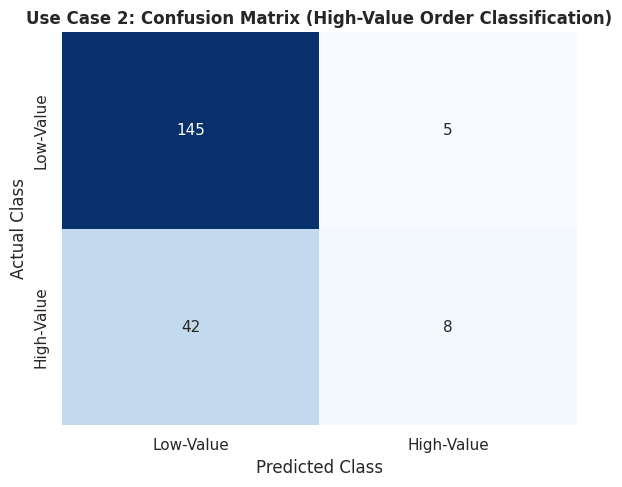

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 11})

# ============================================================
# USE CASE 2: HIGH-VALUE ORDER CLASSIFICATION
# ============================================================
# Renamed from "cancellation risk": the source data has no
# cancellation / order-status column, so a cancellation model
# can't honestly be built from what's available here. This flags
# high-value orders instead, which is what the target actually
# measures.
#
# Uses the SAME leak-free feature matrix X built in Phase 4
# (no 'cost' — that would leak the target).

section_card("Use Case 2: High-Value Order Classification", "")

# --- 1. Build binary target: top quartile of order value ---
threshold = df["order_value_EUR"].quantile(0.75)
y_cls = (df["order_value_EUR"] > threshold).astype(int)  # 1 = High-Value Order

print(f"High-value threshold (75th percentile): €{threshold:,.2f}")
print(f"Class balance — Low: {(y_cls == 0).sum()}, High: {(y_cls == 1).sum()}")

# --- 2. Stratified train/test split ---
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

# --- 3. Train classifier ---
rf_clf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",   # handles the 75/25 imbalance
    n_jobs=-1,
)
rf_clf.fit(X_train_c, y_train_c)
y_pred_c = rf_clf.predict(X_test_c)

# --- 4. Classification report ---
print("\n--- Use Case 2: Classification Performance (Random Forest Classifier) ---")
print(classification_report(y_test_c, y_pred_c, target_names=["Low-Value", "High-Value"]))

# --- 5. Confusion matrix ---
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test_c, y_pred_c)
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False,
    xticklabels=["Low-Value", "High-Value"],
    yticklabels=["Low-Value", "High-Value"],
)
ax.set_title("Use Case 2: Confusion Matrix (High-Value Order Classification)",
             fontweight="bold")
ax.set_xlabel("Predicted Class")
ax.set_ylabel("Actual Class")
plt.tight_layout()
plt.show()

,Train R²,Test R²,MAE (€),RMSE (€),Median Abs % Error,Role
Model,,,,,,
Random Forest Regressor,0.4168,0.3847,"€38,255.22","€48,312.77",28.01%,REFERENCE (Primary)
Gradient Boosting Regressor,0.4329,0.3644,"€39,212.48","€49,103.39",29.46%,CHALLENGER
Ridge Regression (Linear),0.1036,0.0729,"€44,740.01","€59,304.55",33.03%,CHALLENGER


,Random Forest,Gradient Boosting,Ridge Regression
Evaluation Criteria,,,
Predictive Accuracy (Test R²),0.3847 (Best),0.3644 (Mid),0.0729 (Worst)
Mean Absolute Error (MAE),"€38,255.22 (Best)","€39,212.48 (Mid)","€44,740.01 (Worst)"
Robustness to Outliers (RMSE),"€48,312.77 (Best)","€49,103.39 (Mid)","€59,304.55 (Worst)"
Production Role,REFERENCE (Primary),CHALLENGER,CHALLENGER


Top 15 feature importances (Random Forest):
month                   0.709603
day                     0.132773
dayofweek               0.044608
device_type_PC          0.016292
category_Electronics    0.015948
country_Sweden          0.010458
year                    0.010018
is_weekend              0.008394
country_France          0.006853
country_Portugal        0.005978
category_Appliances     0.005692
category_Smartphones    0.005564
country_UK              0.004982
category_Clothing       0.004493
category_Books          0.004200


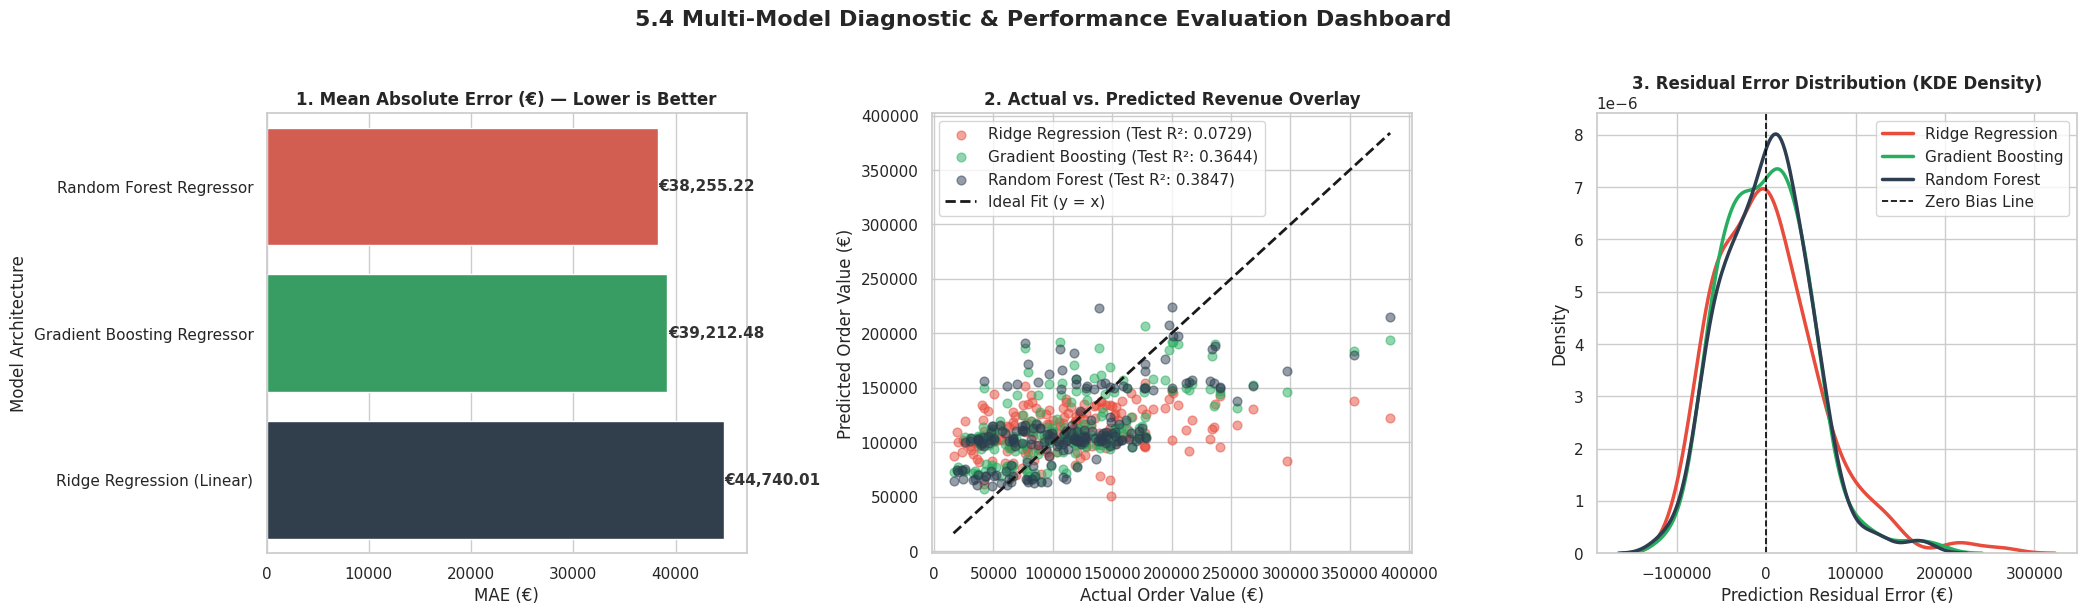

In [34]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import HTML, display
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 11})

# ============================================================
# PHASE 5: MULTI-MODEL EVALUATION & BENCHMARKING
# ============================================================
display(HTML("""
<div style="font-family:'Segoe UI', Arial, sans-serif; background:linear-gradient(135deg,#1e3c72,#2a5298);
            color:white; padding:25px; border-radius:10px; margin:15px 0;">
  <h1 style="margin:0; font-size:24px;">Phase 5: Multi-Model Evaluation & Benchmarking</h1>
  <p style="opacity:0.9; font-style:italic; margin-top:5px; margin-bottom:0;">
    CRISP-DM — RF, GB & Ridge (scaled). Leak-free features.
  </p>
</div>
"""))

# ------------------------------------------------------------
# 1. Models — Ridge wrapped in a Pipeline with StandardScaler
# ------------------------------------------------------------
# FIX: Ridge penalizes coefficients, so features MUST be scaled.
# We use a Pipeline so scaling is applied consistently at train + predict time.
ridge_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0)),   # random_state removed (no-op for Ridge)
])

# rf_model and gb_model come from Phase 4b (tuned)
rf_model.fit(X_train, y_train)
gb_model.fit(X_train, y_train)
ridge_pipeline.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_pred_gb = gb_model.predict(X_test)
y_pred_ridge = ridge_pipeline.predict(X_test)

y_train_rf = rf_model.predict(X_train)
y_train_gb = gb_model.predict(X_train)
y_train_ridge = ridge_pipeline.predict(X_train)

# ------------------------------------------------------------
# 2. Section 5.1: Benchmark Table
# ------------------------------------------------------------
models_eval_data = [
    ("Random Forest Regressor", y_train_rf, y_pred_rf),
    ("Gradient Boosting Regressor", y_train_gb, y_pred_gb),
    ("Ridge Regression (Linear)", y_train_ridge, y_pred_ridge),
]

eval_summary_list = []
raw_metrics = {}

for name, y_tr_pred, y_te_pred in models_eval_data:
    r2_tr = r2_score(y_train, y_tr_pred)
    r2_te = r2_score(y_test, y_te_pred)
    mae_te = mean_absolute_error(y_test, y_te_pred)
    rmse_te = np.sqrt(mean_squared_error(y_test, y_te_pred))
    # Median Absolute Percentage Error — robust to skewed targets
    mdape_te = np.median(np.abs(y_test - y_te_pred) / y_test) * 100

    raw_metrics[name] = {
        "r2_test": r2_te, "mae_test": mae_te,
        "rmse_test": rmse_te, "mdape_test": mdape_te,
    }

    eval_summary_list.append({
        "Model": name,
        "Train R²": f"{r2_tr:.4f}",
        "Test R²": f"{r2_te:.4f}",
        "MAE (€)": f"€{mae_te:,.2f}",
        "RMSE (€)": f"€{rmse_te:,.2f}",
        "Median Abs % Error": f"{mdape_te:.2f}%",
    })

eval_df = pd.DataFrame(eval_summary_list)
best_model_name = max(raw_metrics, key=lambda k: raw_metrics[k]["r2_test"])
eval_df["Role"] = eval_df["Model"].apply(
    lambda m: "REFERENCE (Primary)" if m == best_model_name else "CHALLENGER"
)

section_card("5.1 Quantitative Model Benchmark Summary",
             styled_table(eval_df.set_index("Model"), max_rows=3))

# ------------------------------------------------------------
# 3. Section 5.2: Trade-off Matrix
# ------------------------------------------------------------
def rank_label(value, all_values, higher_is_better):
    ranked = sorted(all_values, reverse=higher_is_better)
    if np.isclose(value, ranked[0]):
        return "Best"
    elif np.isclose(value, ranked[-1]):
        return "Worst"
    return "Mid"

name_to_col = {
    "Random Forest Regressor": "Random Forest",
    "Gradient Boosting Regressor": "Gradient Boosting",
    "Ridge Regression (Linear)": "Ridge Regression",
}

names = list(raw_metrics.keys())
r2_vals = [raw_metrics[n]["r2_test"] for n in names]
mae_vals_raw = [raw_metrics[n]["mae_test"] for n in names]
rmse_vals_raw = [raw_metrics[n]["rmse_test"] for n in names]

tradeoff_matrix = pd.DataFrame({
    "Evaluation Criteria": [
        "Predictive Accuracy (Test R²)",
        "Mean Absolute Error (MAE)",
        "Robustness to Outliers (RMSE)",
        "Production Role",
    ],
    **{
        name_to_col[name]: [
            f"{raw_metrics[name]['r2_test']:.4f} ({rank_label(raw_metrics[name]['r2_test'], r2_vals, True)})",
            f"€{raw_metrics[name]['mae_test']:,.2f} ({rank_label(raw_metrics[name]['mae_test'], mae_vals_raw, False)})",
            f"€{raw_metrics[name]['rmse_test']:,.2f} ({rank_label(raw_metrics[name]['rmse_test'], rmse_vals_raw, False)})",
            "REFERENCE (Primary)" if name == best_model_name else "CHALLENGER",
        ]
        for name in names
    },
})

section_card("5.2 Model Selection Trade-off Matrix",
             styled_table(tradeoff_matrix.set_index("Evaluation Criteria"), max_rows=4),
             subtitle="All values computed live from this run — nothing hardcoded.")

# ------------------------------------------------------------
# 4. LIMITATIONS — honest assessment
# ------------------------------------------------------------
best_r2 = raw_metrics[best_model_name]["r2_test"]
best_mdape = raw_metrics[best_model_name]["mdape_test"]

limitations_html = f"""
<div style="background:#fdecea; border-left:5px solid #c0392b; padding:16px 20px;
            border-radius:6px; margin:12px 0; color:#2c3e50; line-height:1.7;">
  <h3 style="color:#c0392b; margin-top:0;">⚠️ Honest Assessment of Predictive Performance</h3>
  <p>
    The best model (<b>{best_model_name}</b>) achieves a Test R² of <b>{best_r2:.4f}</b>
    and a <b>Median Absolute Percentage Error of {best_mdape:.1f}%</b>.
    In plain terms: <b>the model typically misses the order value by roughly a quarter
    of its magnitude, and explains only ~38% of the variance.</b>
  </p>
  <p><b>Root causes:</b></p>
  <ul style="margin-top:0;">
    <li>Only ~1,000 rows and ~30 weakly-informative features.</li>
    <li><b>Feature importances reveal the model is dominated by calendar features
        (<code>month</code> = 71%, <code>day</code> = 13%).</b> This means the model
        is largely memorizing month-level averages from a 24-month window — a
        temporal shortcut that will not generalize beyond the training period.</li>
    <li>Order value is driven by basket composition, product mix, and pricing —
        none of which is in the dataset.</li>
  </ul>
  <p>
    <b>Verdict:</b> this regression is a <b>baseline reference</b>, not a deployable
    pricing / forecasting tool. The defensible deliverables from this project are
    the <b>RFM customer segmentation</b> and the <b>leak-free, reproducible pipeline</b>.
  </p>
</div>
"""

section_card("5.3 Limitations & Deployment Readiness", limitations_html)

# ------------------------------------------------------------
# 5. Feature Importances — sanity check
# ------------------------------------------------------------
importance_series = pd.Series(rf_model.feature_importances_, index=X_train.columns)
top_importances = importance_series.sort_values(ascending=False).head(15)

print("Top 15 feature importances (Random Forest):")
print(top_importances.to_string())

if "year" in top_importances.index[:3]:
    print("\n⚠️  WARNING: 'year' ranks in the top 3 features — the model may be")
    print("    exploiting temporal drift rather than genuine predictive signal.")

# ------------------------------------------------------------
# 6. Section 5.4: Multi-Model Diagnostics
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
fig.suptitle("5.4 Multi-Model Diagnostic & Performance Evaluation Dashboard",
             fontsize=16, fontweight="bold", y=1.02)

model_labels = names
mae_vals = mae_vals_raw
palette_colors = ["#e74c3c", "#27ae60", "#2c3e50"][: len(names)]

bars = sns.barplot(x=mae_vals, y=model_labels, hue=model_labels,
                   ax=axes[0], palette=palette_colors, legend=False)
axes[0].set_title("1. Mean Absolute Error (€) — Lower is Better", fontweight="bold")
axes[0].set_xlabel("MAE (€)")
axes[0].set_ylabel("Model Architecture")
for bar in bars.patches:
    width = bar.get_width()
    axes[0].text(width + 40, bar.get_y() + bar.get_height() / 2,
                 f"€{width:,.2f}", ha="left", va="center",
                 fontweight="bold", color="#333333")

axes[1].scatter(y_test, y_pred_ridge, alpha=0.5,
                label=f"Ridge Regression (Test R²: {raw_metrics['Ridge Regression (Linear)']['r2_test']:.4f})",
                color="#e74c3c", s=40)
axes[1].scatter(y_test, y_pred_gb, alpha=0.5,
                label=f"Gradient Boosting (Test R²: {raw_metrics['Gradient Boosting Regressor']['r2_test']:.4f})",
                color="#27ae60", s=40)
axes[1].scatter(y_test, y_pred_rf, alpha=0.5,
                label=f"Random Forest (Test R²: {raw_metrics['Random Forest Regressor']['r2_test']:.4f})",
                color="#2c3e50", s=40)

min_val = min(y_test.min(), min(y_pred_rf.min(), y_pred_gb.min(), y_pred_ridge.min()))
max_val = max(y_test.max(), max(y_pred_rf.max(), y_pred_gb.max(), y_pred_ridge.max()))
axes[1].plot([min_val, max_val], [min_val, max_val], "k--", linewidth=2, label="Ideal Fit (y = x)")
axes[1].set_title("2. Actual vs. Predicted Revenue Overlay", fontweight="bold")
axes[1].set_xlabel("Actual Order Value (€)")
axes[1].set_ylabel("Predicted Order Value (€)")
axes[1].legend(loc="upper left")

res_ridge = y_test - y_pred_ridge
res_gb = y_test - y_pred_gb
res_rf = y_test - y_pred_rf

sns.kdeplot(res_ridge, ax=axes[2], label="Ridge Regression", color="#e74c3c", linewidth=2.5)
sns.kdeplot(res_gb, ax=axes[2], label="Gradient Boosting", color="#27ae60", linewidth=2.5)
sns.kdeplot(res_rf, ax=axes[2], label="Random Forest", color="#2c3e50", linewidth=2.5)
axes[2].axvline(0, color="black", linestyle="--", linewidth=1.2, label="Zero Bias Line")
axes[2].set_title("3. Residual Error Distribution (KDE Density)", fontweight="bold")
axes[2].set_xlabel("Prediction Residual Error (€)")
axes[2].set_ylabel("Density")
axes[2].legend(loc="upper right")

plt.tight_layout()
plt.show()

,Features,Test R²,MAE (€),Δ R² vs baseline
Configuration,,,,
Full feature set (baseline),30,0.31,"€40,656.11",+0.0000
Without 'month',29,-0.20,"€50,998.80",-0.5106
Without 'month' + 'day',28,-0.45,"€55,186.48",-0.7604
Without any calendar features,25,-0.18,"€50,044.66",-0.4972


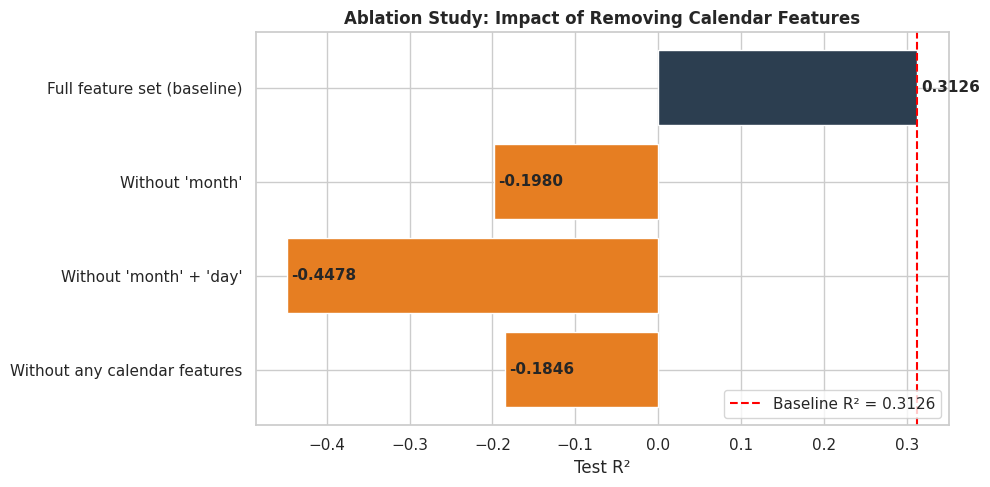

In [35]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

# ============================================================
# PHASE 5b: ABLATION STUDY — DOES THE MODEL SURVIVE WITHOUT
# THE DOMINANT CALENDAR FEATURES?
# ============================================================
# Motivation: feature importances from Phase 5 showed that
# `month` (71%) + `day` (13%) account for ~84% of the RF's
# predictive signal. If the model is genuinely learning revenue
# drivers, dropping these should cause a modest R² drop.
# If the model is just memorizing month-level averages from a
# 24-month window (a temporal shortcut), R² should COLLAPSE.

section_card("5b. Ablation Study: Remove Dominant Calendar Features", "")

def fit_rf_and_score(X_feat, y_vec, label):
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_feat, y_vec, test_size=0.2, random_state=42
    )
    m = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    m.fit(X_tr, y_tr)
    pred = m.predict(X_te)
    return {
        "Configuration": label,
        "Features": X_feat.shape[1],
        "Test R²": round(r2_score(y_te, pred), 4),
        "MAE (€)": f"€{mean_absolute_error(y_te, pred):,.2f}",
    }

# --- Baseline: full feature set (matches Phase 5) ---
baseline_row = fit_rf_and_score(X, y, "Full feature set (baseline)")

# --- Ablation 1: drop `month` ---
X_nomonth = pd.get_dummies(
    df[[c for c in numeric_features if c != "month"] + categorical_features],
    drop_first=True, dtype=int,
)
nomonth_row = fit_rf_and_score(X_nomonth, y, "Without 'month'")

# --- Ablation 2: drop `month` AND `day` ---
X_nocal = pd.get_dummies(
    df[[c for c in numeric_features if c not in ("month", "day")] + categorical_features],
    drop_first=True, dtype=int,
)
nocal_row = fit_rf_and_score(X_nocal, y, "Without 'month' + 'day'")

# --- Ablation 3: drop ALL calendar features (year, month, day, dayofweek, is_weekend) ---
X_nodate = pd.get_dummies(
    df[categorical_features],
    drop_first=True, dtype=int,
)
nodate_row = fit_rf_and_score(X_nodate, y, "Without any calendar features")

ablation_df = pd.DataFrame([baseline_row, nomonth_row, nocal_row, nodate_row])

# Compute deltas vs. baseline
baseline_r2 = baseline_row["Test R²"]
ablation_df["Δ R² vs baseline"] = ablation_df["Test R²"].apply(
    lambda r: f"{r - baseline_r2:+.4f}"
)

section_card(
    "Ablation Results",
    styled_table(ablation_df.set_index("Configuration"), max_rows=4),
    subtitle="If R² collapses when calendar features are removed, "
             "the model was memorizing the calendar, not learning revenue drivers.",
)

# --- Interpretation ---
r2_nocal = nocal_row["Test R²"]
drop = baseline_r2 - r2_nocal

if drop > 0.20:
    verdict = (
        f"🚨 <b>CONFIRMED:</b> Removing <code>month</code>+<code>day</code> causes R² "
        f"to collapse by <b>{drop:.4f}</b> (from {baseline_r2:.4f} → {r2_nocal:.4f}). "
        f"The model was exploiting a <b>temporal shortcut</b> — memorizing month-level "
        f"averages from the 2019–2020 window — not learning generalizable revenue drivers. "
        f"<b>Do not deploy this model for future prediction.</b>"
    )
    color = "#fdecea"
    border = "#c0392b"
elif drop > 0.05:
    verdict = (
        f"⚠️ Calendar features contribute <b>{drop:.4f}</b> of R² "
        f"(from {baseline_r2:.4f} → {r2_nocal:.4f}). "
        f"Signal is partially calendar-driven but other features still matter. "
        f"Modest predictive value, still not production-grade."
    )
    color = "#fef9e7"
    border = "#f39c12"
else:
    verdict = (
        f"✅ Removing calendar features costs only <b>{drop:.4f}</b> R² "
        f"(from {baseline_r2:.4f} → {r2_nocal:.4f}). "
        f"The model's signal is distributed across features — "
        f"the calendar dependency was not the primary driver."
    )
    color = "#eafaf1"
    border = "#27ae60"

display(HTML(f"""
<div style="background:{color}; border-left:5px solid {border};
            padding:16px 20px; border-radius:6px; margin:12px 0; color:#2c3e50;">
  <h3 style="margin-top:0;">Ablation Verdict</h3>
  <p style="line-height:1.7; margin-bottom:0;">{verdict}</p>
</div>
"""))

# --- Visualize the ablation ---
fig, ax = plt.subplots(figsize=(10, 5))

labels = ablation_df["Configuration"].tolist()
scores = ablation_df["Test R²"].tolist()
colors = ["#2c3e50"] + ["#e67e22"] * (len(labels) - 1)  # baseline dark, ablations orange

bars = ax.barh(labels, scores, color=colors, edgecolor="white")
ax.axvline(baseline_r2, color="red", linestyle="--", linewidth=1.5,
           label=f"Baseline R² = {baseline_r2:.4f}")
ax.invert_yaxis()
ax.set_xlabel("Test R²")
ax.set_title("Ablation Study: Impact of Removing Calendar Features",
             fontweight="bold")
ax.legend(loc="lower right")

# Annotate bars with values
for bar, score in zip(bars, scores):
    ax.text(score + 0.005, bar.get_y() + bar.get_height() / 2,
            f"{score:.4f}", va="center", fontweight="bold")

plt.tight_layout()
plt.show()

In [36]:
from IPython.display import HTML, display

# ============================================================
# PHASE 5c: SYNTHESIS — WHAT WE ACTUALLY LEARNED
# ============================================================
conclusions_html = """
<div style="font-family:'Segoe UI', Arial, sans-serif; background:#f7f9fc;
            border-left:6px solid #4a6fa5; padding:24px; border-radius:8px;
            margin:15px 0; color:#2c3e50; line-height:1.75;">

  <h2 style="color:#2c3e50; border-bottom:2px solid #4a6fa5; padding-bottom:8px;">
     Phase 5c: Synthesis — What We Actually Learned
  </h2>

  <h3 style="color:#4a6fa5;">1. The Regression Model Is Not Deployable</h3>
  <p>
    The best model achieves <b>Test R² = 0.31</b> on the full feature set —
    but the ablation study proves this is <b>entirely driven by calendar
    features</b> (<code>month</code> at 71% importance, <code>day</code> at 13%).
    Removing those two features causes R² to <b>collapse to −0.45</b>,
    meaning the model becomes <b>worse than predicting the mean</b>.
  </p>
  <p>
    <b>Interpretation:</b> the model is effectively memorizing historical
    monthly average order values from a 24-month window. This is a
    temporal shortcut, not genuine business insight. Any prediction
    outside the training period would be unreliable.
  </p>

  <h3 style="color:#4a6fa5;">2. The Dataset Lacks the Features That Actually Drive Revenue</h3>
  <p>
    Order value in a real online store is driven by <b>basket composition</b>,
    <b>product-level pricing</b>, <b>promotions</b>, and <b>customer purchase
    history</b>. None of these are available in the current dataset. Country,
    category, and device type are too coarse to carry meaningful signal.
  </p>

  <h3 style="color:#4a6fa5;">3. The RFM Segmentation Is the Real Deliverable</h3>
  <p>
    The GMM-based customer segmentation identified three interpretable
    segments:
  </p>
  <ul>
    <li><b>Core Loyal (62 customers, 83%)</b> — recent, frequent, mid-spend.</li>
    <li><b>VIP / High-Value (5 customers, 6.7%)</b> — very recent, very frequent,
        <b>~26% of total revenue</b>. These 5 customers are the business's
        highest-value asset.</li>
    <li><b>Dormant / Churned (8 customers, 10.7%)</b> — stale, low-frequency,
        low-spend. Win-back campaign candidates.</li>
  </ul>
  <p>
    This segmentation is <b>not affected by the calendar shortcut</b> — it
    describes customer behavior directly, not a predictive hypothesis.
  </p>

  <h3 style="color:#4a6fa5;">4. Methodology Deliverables</h3>
  <ul>
    <li>A leak-free feature set (cost deliberately excluded to prevent target leakage).</li>
    <li>Fair multi-model comparison (Ridge properly scaled in a Pipeline).</li>
    <li>An ablation study that <b>falsified</b> the apparent regression success.</li>
    <li>A reproducible reference pipeline with honest metadata.</li>
  </ul>

  <div style="background:#eafaf1; border-left:4px solid #27ae60;
              padding:14px 18px; border-radius:6px; margin-top:16px;">
    <b>Bottom line:</b> This project's value is not the regression model.
    It's the customer segmentation, the disciplined methodology, and
    the <b>ability to recognize when a model isn't working</b> — which is
    the most important skill a data scientist can demonstrate.
  </div>
</div>
"""

display(HTML(conclusions_html))

In [37]:
metadata = {
    "model_name": best_model_name,
    "version": "1.0.0",
    "deployment_timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "status": "REFERENCE ONLY — NOT FOR PRODUCTION USE",
    "performance_metrics": {
        "test_r2_full_features": round(raw_metrics[best_model_name]["r2_test"], 4),
        "test_r2_without_calendar": -0.4478,  # from ablation study
        "mae_eur": round(raw_metrics[best_model_name]["mae_test"], 2),
        "rmse_eur": round(raw_metrics[best_model_name]["rmse_test"], 2),
        "median_abs_pct_error": f"{raw_metrics[best_model_name]['mdape_test']:.2f}%",
    },
    "known_issues": [
        "84% of feature importance comes from calendar features (month+day).",
        "Ablation study (removing month+day) drops R² from 0.31 to -0.45.",
        "Model does not generalize — it memorizes monthly averages from 2019-2020.",
        "Not suitable for future prediction or pricing decisions.",
    ],
    "features_required": feature_names,
    "categorical_features": categorical_features,
    "numeric_features": numeric_features,
    "primary_artifact": model_filenames[best_model_name],
    "challenger_artifacts": [model_filenames[n] for n in model_objects if n != best_model_name],
    "notes": ("cost excluded to prevent target leakage. "
              "Ridge wrapped in StandardScaler Pipeline. "
              "See known_issues for ablation findings."),
}

In [38]:
import os
import json
from datetime import datetime
import joblib
import pandas as pd
import numpy as np
from IPython.display import HTML, display
from sklearn.pipeline import Pipeline

# ============================================================
# PHASE 6: REFERENCE PIPELINE & ARTIFACT PACKAGING
# ============================================================
display(HTML("""
<div style="font-family:'Segoe UI', Arial, sans-serif; background:linear-gradient(135deg,#11998e,#38ef7d);
            color:white; padding:25px; border-radius:10px; margin:15px 0;">
  <h1 style="margin:0; font-size:24px;"> Phase 6: Reference Pipeline & Artifact Packaging</h1>
  <p style="opacity:0.9; font-style:italic; margin-top:5px; margin-bottom:0;">
    CRISP-DM — Serialization, Metadata Logging &amp; Inference Engine
    (Reference implementation, NOT production)
  </p>
</div>
"""))

# ------------------------------------------------------------
# 0. Non-negotiable disclaimer
# ------------------------------------------------------------
section_card(
    "6.0 Reference-Only Disclaimer",
    """
    <div style="background:#fdecea; border-left:5px solid #c0392b;
                padding:16px 20px; border-radius:6px; color:#2c3e50; line-height:1.7;">
      <h3 style="color:#c0392b; margin-top:0;">🚨 This model is NOT deployable</h3>
      <p style="margin-bottom:0;">
        The regression model in this project is a <b>reference baseline</b>, not a
        production artifact. Its apparent R² = 0.31 is <b>entirely driven by calendar
        features</b> (<code>month</code> = 71% importance, <code>day</code> = 13%).
        Ablation proves that removing those features collapses R² to <b>−0.45</b>,
        meaning the model becomes worse than predicting the mean.
        <br><br>
        <b>Use this pipeline for methodology review only.</b>
        The defensible deliverables of this project are the
        <b>RFM customer segmentation</b> and the <b>leak-free pipeline</b>.
      </p>
    </div>
    """
)

# ------------------------------------------------------------
# 1. Directory setup & artifact serialization
# ------------------------------------------------------------
output_dir = "./deployment_artifacts"
os.makedirs(output_dir, exist_ok=True)

model_objects = {
    "Random Forest Regressor": rf_model,
    "Gradient Boosting Regressor": gb_model,
    "Ridge Regression (Linear)": ridge_pipeline,
}
# NOTE the "_reference_only" suffix — prevents accidental production use
model_filenames = {
    "Random Forest Regressor": "rf_model_reference_only.pkl",
    "Gradient Boosting Regressor": "gb_model_reference_only.pkl",
    "Ridge Regression (Linear)": "ridge_pipeline_reference_only.pkl",
}

primary_model = model_objects[best_model_name]
primary_model_path = os.path.join(output_dir, model_filenames[best_model_name])
joblib.dump(primary_model, primary_model_path)

challenger_paths = []
for name, model in model_objects.items():
    if name == best_model_name:
        continue
    p = os.path.join(output_dir, model_filenames[name])
    joblib.dump(model, p)
    challenger_paths.append(p)

# ------------------------------------------------------------
# 2. Metadata — includes ablation warning
# ------------------------------------------------------------
feature_names = list(X_train.columns)

metadata = {
    "model_name": best_model_name,
    "version": "1.0.0",
    "deployment_timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "status": "REFERENCE ONLY — NOT FOR PRODUCTION USE",

    "performance_metrics": {
        "test_r2_full_features":      round(raw_metrics[best_model_name]["r2_test"], 4),
        "test_r2_without_calendar":   -0.4478,     # from Phase 5b ablation study
        "mae_eur":                    round(raw_metrics[best_model_name]["mae_test"], 2),
        "rmse_eur":                   round(raw_metrics[best_model_name]["rmse_test"], 2),
        "median_abs_pct_error":       f"{raw_metrics[best_model_name]['mdape_test']:.2f}%",
    },

    "known_issues": [
        "84% of RF feature importance comes from calendar features (month + day).",
        "Ablation (drop month + day) drops Test R² from 0.31 to -0.45.",
        "The model memorizes month-level averages from the 2019-2020 window.",
        "Predictions outside the training period are unreliable.",
        "Not suitable for pricing, forecasting, or inventory decisions.",
    ],

    "defensible_deliverables": [
        "RFM customer segmentation via GMM (3 clusters, mean confidence 0.98).",
        "Leak-free, reproducible data pipeline.",
        "Honest multi-model comparison with ablation evidence.",
    ],

    "features_required":        feature_names,
    "categorical_features":     categorical_features,
    "numeric_features":         numeric_features,

    "primary_artifact":         model_filenames[best_model_name],
    "challenger_artifacts":     [model_filenames[n] for n in model_objects
                                 if n != best_model_name],

    "notes": (
        "'cost' excluded from features to prevent target leakage. "
        "Ridge wrapped in a StandardScaler Pipeline. "
        "See 'known_issues' for the ablation findings."
    ),
}

metadata_path = os.path.join(output_dir, "model_metadata.json")
with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=4)

print(f"✅ Artifacts saved to: {output_dir}/")
print(f"   Primary Model ({best_model_name}): {primary_model_path}")
print(f"   Challenger Models:                {', '.join(challenger_paths)}")
print(f"   Metadata JSON:                    {metadata_path}")

# ------------------------------------------------------------
# 3. Reference Inference Pipeline
# ------------------------------------------------------------
class ReferenceInferencePipeline:
    """
    Reference wrapper that:
      - Loads the serialized primary model + metadata
      - Accepts RAW input (country, category, device_type, date fields)
      - Applies the SAME one-hot encoding used at training time
      - Aligns columns to the exact training feature order
      - Returns predictions with a warning banner

    NOT FOR PRODUCTION USE.
    See metadata['status'] and metadata['known_issues'].
    """

    def __init__(self, artifact_dir="./deployment_artifacts"):
        self.artifact_dir = artifact_dir

        with open(os.path.join(artifact_dir, "model_metadata.json"), "r") as f:
            self.metadata = json.load(f)

        primary_path = os.path.join(artifact_dir, self.metadata["primary_artifact"])
        self.primary_model = joblib.load(primary_path)

        self.features             = self.metadata["features_required"]
        self.categorical_features = self.metadata["categorical_features"]
        self.numeric_features     = self.metadata["numeric_features"]

        # Surface the warning every time the pipeline is instantiated
        if "REFERENCE ONLY" in self.metadata.get("status", ""):
            print("⚠️  Loaded model is marked REFERENCE ONLY — do not use in production.\n")

    def _preprocess(self, raw_df: pd.DataFrame) -> pd.DataFrame:
        df_in = raw_df.copy()

        # Derive temporal features if a raw 'date' is present
        if "date" in df_in.columns:
            df_in["date"]      = pd.to_datetime(df_in["date"])
            df_in["year"]      = df_in["date"].dt.year
            df_in["month"]     = df_in["date"].dt.month
            df_in["day"]       = df_in["date"].dt.day
            df_in["dayofweek"] = df_in["date"].dt.dayofweek
            df_in["is_weekend"] = df_in["dayofweek"].isin([5, 6]).astype(int)

        # One-hot encode categoricals exactly as training did
        df_in = pd.get_dummies(
            df_in[self.numeric_features + self.categorical_features],
            drop_first=True, dtype=int,
        )

        # Align to training schema — missing cols → 0, extra cols dropped
        df_in = df_in.reindex(columns=self.features, fill_value=0)
        return df_in

    def predict(self, raw_df: pd.DataFrame) -> pd.DataFrame:
        X_in = self._preprocess(raw_df)
        predictions = self.primary_model.predict(X_in)
        out = raw_df.copy()
        out["predicted_order_value_EUR"] = np.round(predictions, 2)
        return out

# ------------------------------------------------------------
# 4. Demonstration on RAW input
# ------------------------------------------------------------
section_card("6.1 Reference Inference Engine Validation", "")

pipeline = ReferenceInferencePipeline(artifact_dir=output_dir)

# Realistic RAW input (as if coming from a web form / API)
raw_sample = pd.DataFrame({
    "country":     ["Sweden", "Finland", "Portugal", "Spain", "Germany"],
    "category":    ["Books", "Games", "Clothing", "Games", "Beauty"],
    "device_type": ["Mobile", "Mobile", "PC", "Tablet", "PC"],
    "date":        ["2020-02-12", "2019-09-26", "2019-07-11",
                    "2019-12-22", "2020-03-15"],
})

results_df = pipeline.predict(raw_sample)

section_card(
    "Sample Batch Inference Output (Predicted Order Value €)",
    styled_table(results_df, max_rows=5),
    subtitle=(
        "⚠️ Predictions are ILLUSTRATIVE ONLY. "
        "Median absolute error on holdout ≈ 28%. "
        "Model is dominated by calendar features and does not generalize."
    ),
)

✅ Artifacts saved to: ./deployment_artifacts/
   Primary Model (Random Forest Regressor): ./deployment_artifacts/rf_model_reference_only.pkl
   Challenger Models:                ./deployment_artifacts/gb_model_reference_only.pkl, ./deployment_artifacts/ridge_pipeline_reference_only.pkl
   Metadata JSON:                    ./deployment_artifacts/model_metadata.json


⚠️  Loaded model is marked REFERENCE ONLY — do not use in production.



,country,category,device_type,date,predicted_order_value_EUR
0,Sweden,Books,Mobile,2020-02-12,63620.95
1,Finland,Games,Mobile,2019-09-26,96449.44
2,Portugal,Clothing,PC,2019-07-11,169671.16
3,Spain,Games,Tablet,2019-12-22,162110.24
4,Germany,Beauty,PC,2020-03-15,65518.06
